# Klasifikace dat ve 2D prostoru

Tento notebook se zabývá úlohou klasifikace s učitelem na 2D datech. Cílem je natrénovat a porovnat různé typy klasifikátorů, vizualizovat jejich rozhodovací hranice a vyhodnotit jejich přesnost na testovacích datech a rychlost trénování.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Import tvých vlastních funkcí a tříd
from generic import load_data, plot_clusters, plot_boundaries
import classification as cl

# Globální slovníky pro ukládání výsledků
results_accuracy = {}
results_time = {}

def evaluate_accuracy(classifier, X, y):
    """
    Samostatná globální funkce pro výpočet přesnosti na libovolných datech.
    """
    correct = sum(1 for x_val, y_val in zip(X, y) if classifier.predict(x_val) == y_val)
    return correct / len(X)

def run_evaluation(clf_name, classifier, X_train, y_train, X_test, y_test, plot_title=None, **kwargs):
    """
    Univerzální funkce, která natrénuje jakýkoliv klasifikátor (včetně NN s parametry),
    změří čas, spočítá přesnost a volitelně vykreslí rozhodovací hranice.
    """
    # Měření času trénování
    start_time = time.perf_counter()
    # Pomocí **kwargs předáme specifické argumenty jako epochs nebo sgd
    train_output = classifier.train(X_train, y_train, **kwargs)
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    
    # Výpočet přesnosti na testovacích datech pomocí naší globální funkce
    accuracy_pct = evaluate_accuracy(classifier, X_test, y_test) * 100
    
    # Uložení do statistik
    results_accuracy[clf_name] = accuracy_pct
    results_time[clf_name] = elapsed_ms
    
    print(f"[{clf_name}] -> Čas: {elapsed_ms:.2f} ms | Přesnost: {accuracy_pct:.1f}%")
    
    # Vykreslení hranic rozhodování
    if plot_title:
        plot_boundaries(classifier, X_train, y_train, f"{plot_title} (Přesnost: {accuracy_pct:.1f}%)")
        
    return train_output  # Vrátí loss_history u NN (nebo None u ostatních)

Velikost trénovací množiny: 638 bodů
Velikost testovací množiny:  71 bodů


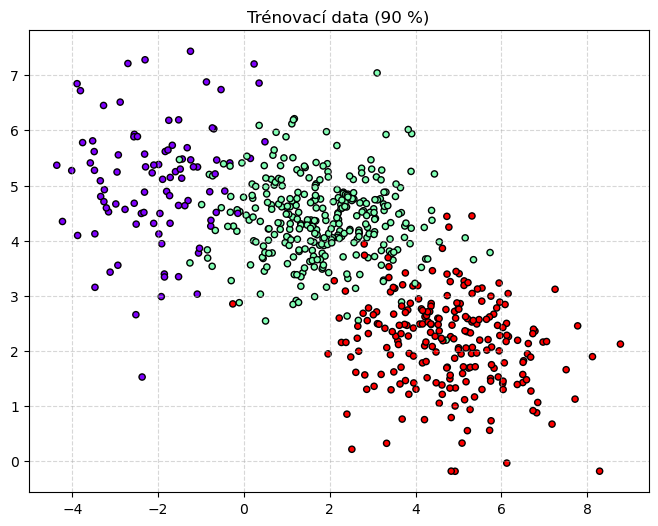

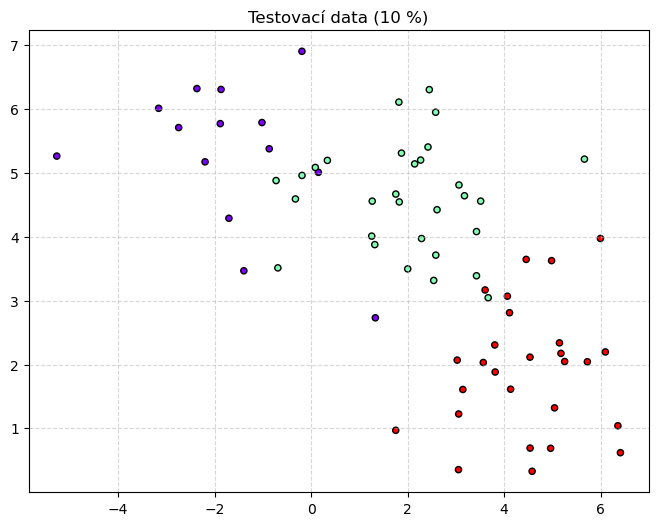

In [2]:
# Načtení dat ze souboru
raw_data = load_data("data_kla.txt")

# Příprava matic X (souřadnice) a y (třídy)
X = np.array([[row[0], row[1]] for row in raw_data], dtype=np.float32)
y = np.array([row[2] for row in raw_data], dtype=np.int32)

# Náhodné rozdělení na trénovací a testovací množinu v poměru 90:10
np.random.seed(42)  # Zajištění replikovatelnosti rozdělení
X_train, y_train, X_test, y_test = cl.split_data(X, y, ratio=0.9)

print(f"Velikost trénovací množiny: {len(X_train)} bodů")
print(f"Velikost testovací množiny:  {len(X_test)} bodů")

# Vizuální kontrola rozdělení trénovacích dat
plot_clusters(X_train, y_train, "Trénovací data (90 %)")
plot_clusters(X_test, y_test, "Testovací data (10 %)")

## Úkol 4a: Klasifikátor podle minimální vzdálenosti

Tento klasifikátor přiřazuje body k nejbližšímu reprezentantovi třídy. Vyzkoušíme dvě varianty:
1. **1 reprezentant na třídu:** Každá třída je reprezentována pouze svým geometrickým těžištěm.
2. **3 reprezentanti na třídu:** Třídu reprezentuje více bodů získaných pomocí algoritmu K-means.

[Min. Vzdálenost (1 střed)] -> Čas: 3.61 ms | Přesnost: 87.3%


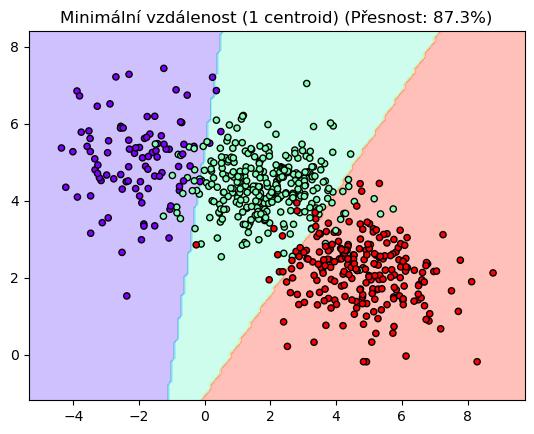

[Min. Vzdálenost (3 středy)] -> Čas: 3.81 ms | Přesnost: 93.0%


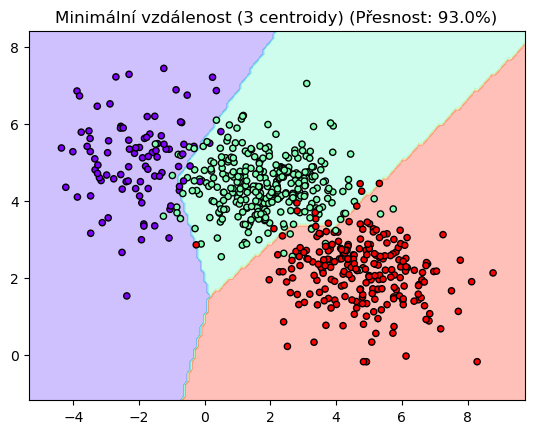

In [3]:
# 1. Jeden střed (těžiště)
clf_min_1 = cl.MinDistanceClassifier(centers_per_class=1)
run_evaluation("Min. Vzdálenost (1 střed)", clf_min_1, X_train, y_train, X_test, y_test, "Minimální vzdálenost (1 centroid)")

# 2. Tři středy (K-means)
clf_min_3 = cl.MinDistanceClassifier(centers_per_class=3)
run_evaluation("Min. Vzdálenost (3 středy)", clf_min_3, X_train, y_train, X_test, y_test, "Minimální vzdálenost (3 centroidy)")

## Úkol 4b: Klasifikátor podle nejbližšího souseda (k-NN)

k-NN je líný klasifikátor (lazy learner), který nevyžaduje explicitní fázi trénování. Porovnáme:
1. **1-NN vs. 2-NN vs. 5-NN** (Většinové hlasování)
2. **5-NN s rozhodovacím pravidlem minimální průměrné vzdálenosti** k sousedům každé třídy

[1-NN (Hlasování)] -> Čas: 0.03 ms | Přesnost: 87.3%


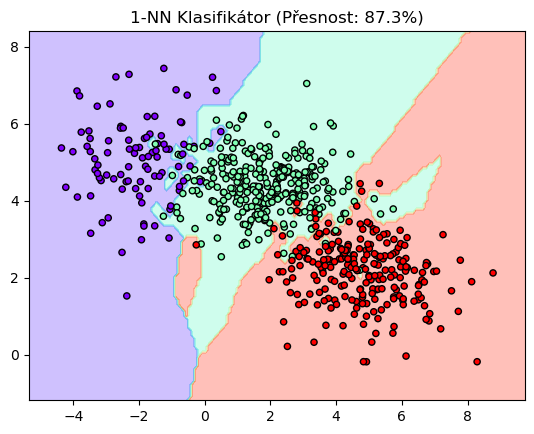

[2-NN (Hlasování)] -> Čas: 0.04 ms | Přesnost: 90.1%


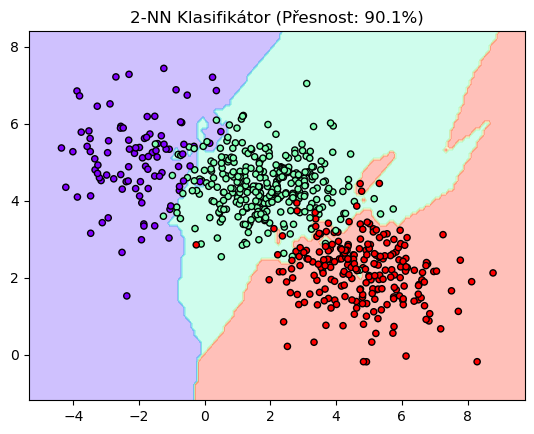

[5-NN (Hlasování)] -> Čas: 0.03 ms | Přesnost: 88.7%


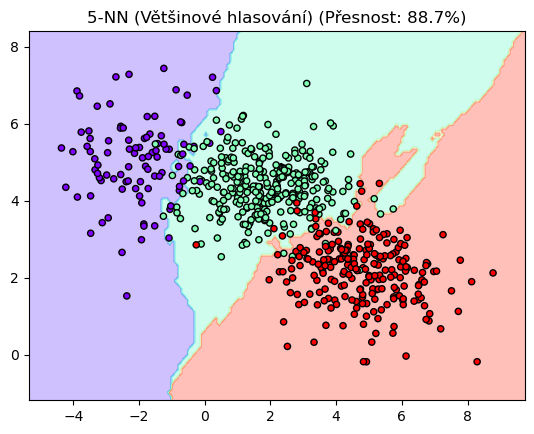

[5-NN (Průměrná vzd.)] -> Čas: 0.02 ms | Přesnost: 91.5%


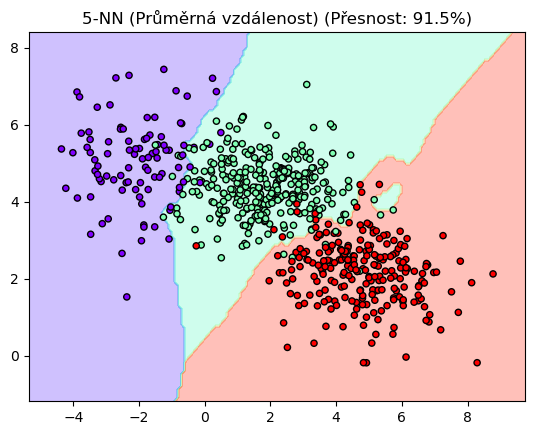

In [4]:
# 1-NN (Hlasování)
clf_1nn = cl.KNNClassifier(k_neighbors=1, vote=True)
run_evaluation("1-NN (Hlasování)", clf_1nn, X_train, y_train, X_test, y_test, "1-NN Klasifikátor")

# 2-NN (Hlasování)
clf_2nn = cl.KNNClassifier(k_neighbors=2, vote=True)
run_evaluation("2-NN (Hlasování)", clf_2nn, X_train, y_train, X_test, y_test, "2-NN Klasifikátor")

# 5-NN (Hlasování)
clf_5nn_vote = cl.KNNClassifier(k_neighbors=5, vote=True)
run_evaluation("5-NN (Hlasování)", clf_5nn_vote, X_train, y_train, X_test, y_test, "5-NN (Většinové hlasování)")

# 5-NN (Průměrná vzdálenost)
clf_5nn_dist = cl.KNNClassifier(k_neighbors=5, vote=False)
run_evaluation("5-NN (Průměrná vzd.)", clf_5nn_dist, X_train, y_train, X_test, y_test, "5-NN (Průměrná vzdálenost)")

## Úkol 4c: Bayesův klasifikátor (QDA)

Klasifikátor odhaduje parametry jednosložkového normálního rozdělení (střední hodnota $\boldsymbol{\mu}$ a plná kovarianční matice $\boldsymbol{\Sigma}$) pro každou třídu. Rozhodovací hranice u této metody bývají kvadratické (paraboly, elipsy).

[Bayesův klasifikátor] -> Čas: 1.16 ms | Přesnost: 95.8%


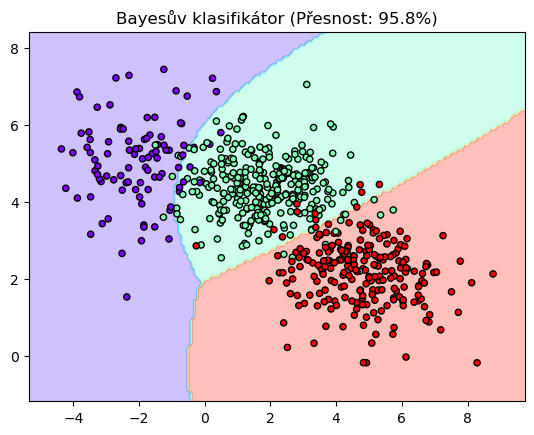

In [5]:
clf_bayes = cl.BayesClassifier()
run_evaluation("Bayesův klasifikátor", clf_bayes, X_train, y_train, X_test, y_test, "Bayesův klasifikátor")

## Úkol 4d: Lineární diskriminační funkce

Lineární klasifikátory trénované metodou učení s učitelem (One-vs-Rest). Porovnáváme:
1. **Rosenblattův algoritmus** (oprava vah nastává hned při překročení nuly)
2. **Metodu konstantních přírůstků** (vyžaduje splnění přísnějšího pásma necitlivosti $b$)
Zkoumáme vliv konstanty učení $\alpha$ na počet potřebných iterací.

Metoda rosenblatt, třída 0, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 1, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 2, alfa 0.1: 1000 iterací
[Rosenblatt (alfa=0.1)] -> Čas: 1630.61 ms | Přesnost: 88.7%


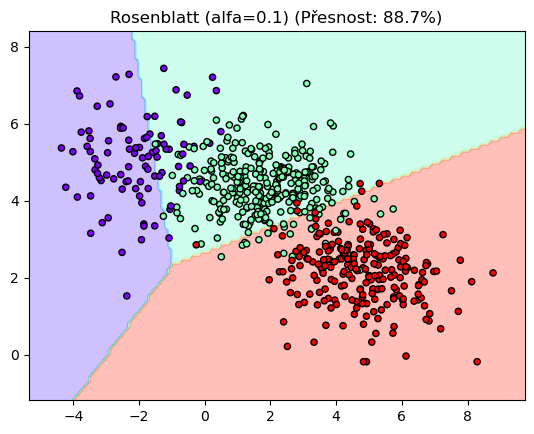

Metoda konst, třída 0, alfa 0.1: 1000 iterací
Metoda konst, třída 1, alfa 0.1: 1000 iterací
Metoda konst, třída 2, alfa 0.1: 1000 iterací
[Konst. Přírůstky (alfa=0.1)] -> Čas: 1664.68 ms | Přesnost: 90.1%


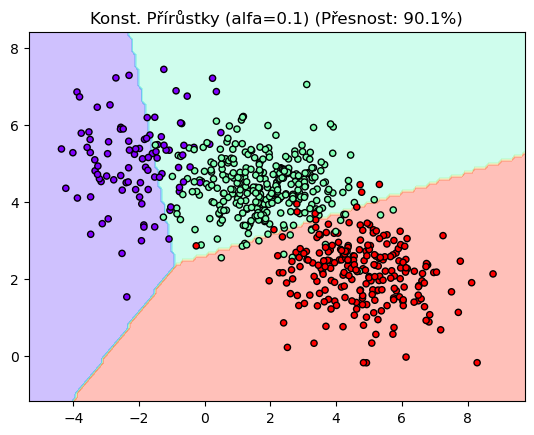

Metoda rosenblatt, třída 0, alfa 0.01: 1000 iterací
Metoda rosenblatt, třída 1, alfa 0.01: 1000 iterací
Metoda rosenblatt, třída 2, alfa 0.01: 1000 iterací
[Rosenblatt (alfa=0.01)] -> Čas: 1649.64 ms | Přesnost: 88.7%


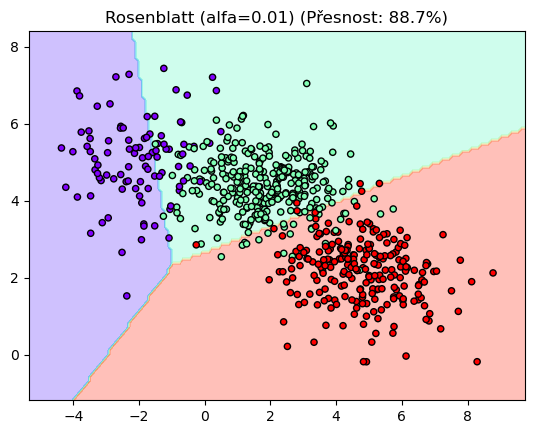

Metoda konst, třída 0, alfa 0.01: 1000 iterací
Metoda konst, třída 1, alfa 0.01: 1000 iterací
Metoda konst, třída 2, alfa 0.01: 1000 iterací
[Konst. Přírůstky (alfa=0.01)] -> Čas: 1747.02 ms | Přesnost: 90.1%


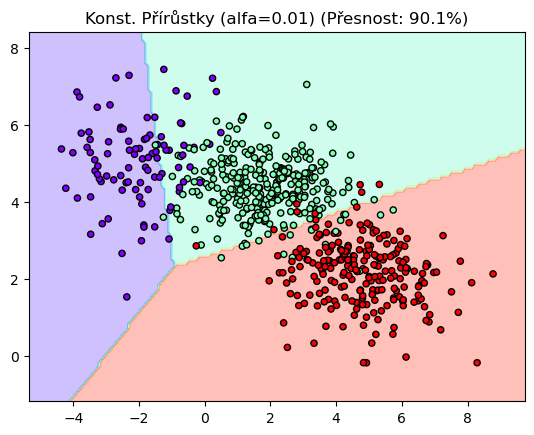

In [6]:
alphas = [0.1, 0.01]

for alpha in alphas:
    # Rosenblatt
    clf_rosen = cl.LinearDiscriminantClassifier(rosenblatt=True, alpha=alpha, max_iters=1000)
    run_evaluation(f"Rosenblatt (alfa={alpha})", clf_rosen, X_train, y_train, X_test, y_test, f"Rosenblatt (alfa={alpha})")
    
    # Konstantní přírůstky s b=1.0
    clf_const = cl.LinearDiscriminantClassifier(rosenblatt=False, alpha=alpha, b=1.0, max_iters=1000)
    run_evaluation(f"Konst. Přírůstky (alfa={alpha})", clf_const, X_train, y_train, X_test, y_test, f"Konst. Přírůstky (alfa={alpha})")

## Úkol 5: Vícevrstvá neuronová síť (MLP)

V této části budeme analyzovat chování jednoduché neuronové sítě.

### Experiment 1: Topologie sítě

Nejprve porovnáme vliv **topologie sítě** (počtu skrytých vrstev a neuronů) při konstantním nastavení parametru učení $\alpha = 0.5$ (Batch GD, 300 epoch).

[NN [2, 3] (Lineární)] -> Čas: 42.86 ms | Přesnost: 91.5%
[NN [2, 8, 3] (1 skr. vrstva)] -> Čas: 62.19 ms | Přesnost: 91.5%
[NN [2, 16, 8, 3] (2 skr. vrstvy)] -> Čas: 132.49 ms | Přesnost: 91.5%


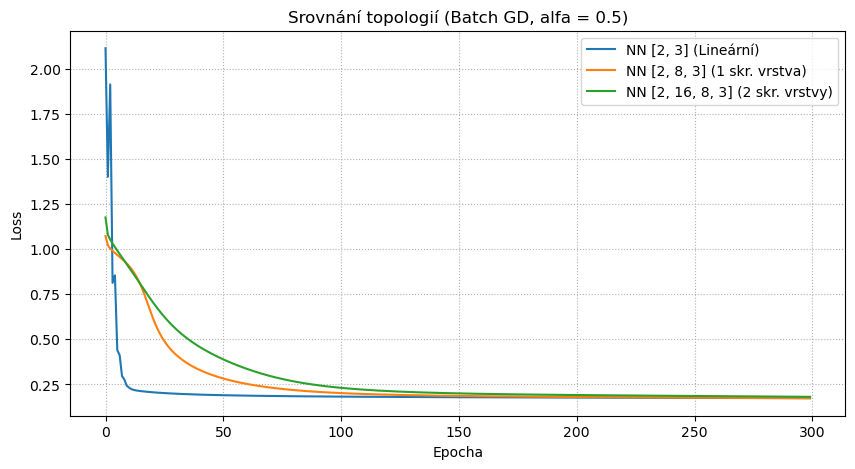

In [7]:
# Srovnání topologií sítě
topologies = {
    "NN [2, 3] (Lineární)": [2, 3],
    "NN [2, 8, 3] (1 skr. vrstva)": [2, 8, 3],
    "NN [2, 16, 8, 3] (2 skr. vrstvy)": [2, 16, 8, 3]
}
base_lr = 0.5
epochs = 300

plt.figure(figsize=(10, 5))
for name, topo in topologies.items():
    # Vytvoření sítě s danou topologií
    nn = cl.SimpleNeuralNetwork(layer_sizes=topo, learning_rate=base_lr)
    
    # Použití run_evaluation! Natrénuje síť, uloží přesnost/čas a vrátí loss_history pro vykreslení
    loss = run_evaluation(name, nn, X_train, y_train, X_test, y_test, epochs=epochs, sgd=False)
    
    plt.plot(loss, label=name)

plt.title("Srovnání topologií (Batch GD, alfa = 0.5)")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

### Experiment 2: Způsob trénování (SGD vs. Batch GD)

Nyní porovnáme rychlost poklesu chybové funkce při použití **dávkového gradientního sestupu (Batch GD)** a **stochastického gradientního sestupu (SGD)** pro topologii `[2, 8, 3]` (alfa = 0.5, 300 epoch).

[NN [2, 8, 3] (Batch)] -> Čas: 108.01 ms | Přesnost: 90.1%


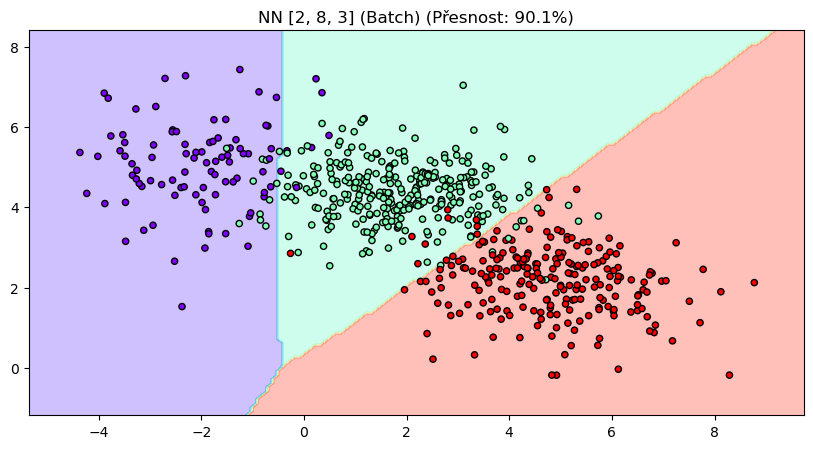

[NN [2, 8, 3] (SGD)] -> Čas: 9269.13 ms | Přesnost: 88.7%


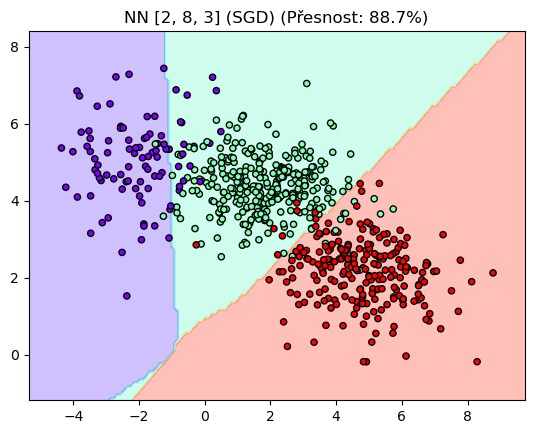

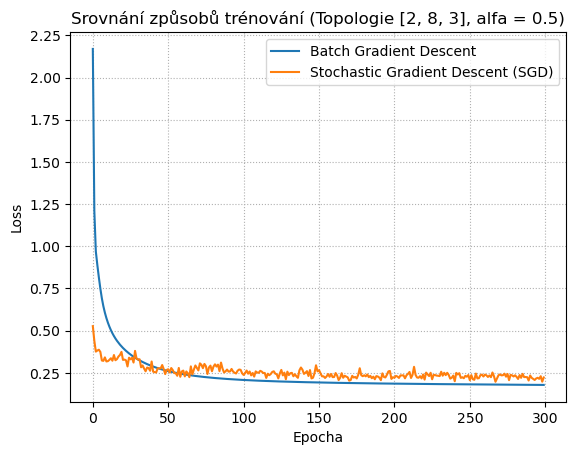

In [8]:
# Srovnání způsobů trénování
topology = [2, 8, 3]
plt.figure(figsize=(10, 5))

# 1. Batch GD
nn_batch = cl.SimpleNeuralNetwork(layer_sizes=topology, learning_rate=base_lr)
loss_batch = run_evaluation(f"NN {topology} (Batch)", nn_batch, X_train, y_train, X_test, y_test, f"NN {topology} (Batch)", epochs=epochs, sgd=False)

# 2. SGD (Stochastic GD)
nn_sgd = cl.SimpleNeuralNetwork(layer_sizes=topology, learning_rate=base_lr)
loss_sgd = run_evaluation(f"NN {topology} (SGD)", nn_sgd, X_train, y_train, X_test, y_test, f"NN {topology} (SGD)", epochs=epochs, sgd=True)

plt.plot(loss_batch, label="Batch Gradient Descent")
plt.plot(loss_sgd, label="Stochastic Gradient Descent (SGD)")
plt.title("Srovnání způsobů trénování (Topologie [2, 8, 3], alfa = 0.5)")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

### Experiment 3: Volba konstanty učení (Learning Rate)

Konstanta učení (learning rate) určuje velikost kroku při úpravě vah. Porovnáme vliv různých hodnot $\alpha \in [0.7, 0.5, 0.2]$ na rychlost konvergence sítě s topologií `[2, 8, 3]` při použití Batch GD (300 epoch).

[NN [2, 8, 3] (alfa = 0.7)] -> Čas: 73.88 ms | Přesnost: 91.5%
[NN [2, 8, 3] (alfa = 0.5)] -> Čas: 61.58 ms | Přesnost: 90.1%
[NN [2, 8, 3] (alfa = 0.2)] -> Čas: 60.65 ms | Přesnost: 90.1%


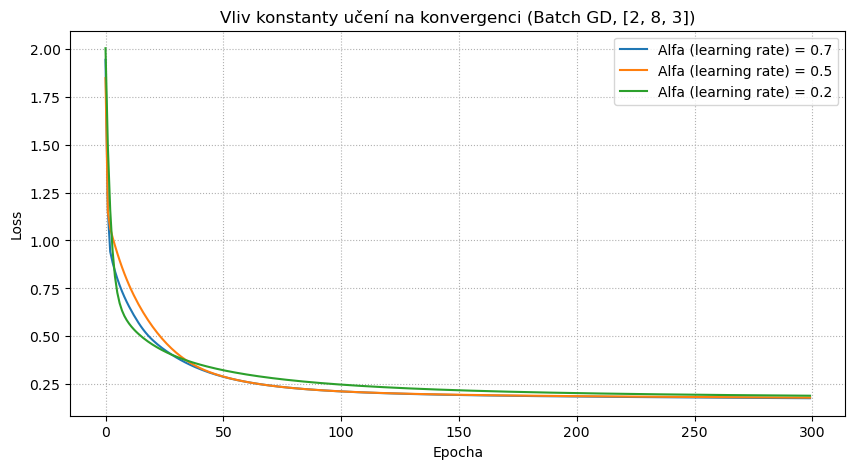

In [9]:
# Srovnání Learning Rates
lrs = [0.7, 0.5, 0.2]

plt.figure(figsize=(10, 5))
for lr in lrs:
    nn = cl.SimpleNeuralNetwork(layer_sizes=topology, learning_rate=lr)
    
    # Spuštění přes run_evaluation pro uložení do statistik
    # Abychom rozlišili názvy v grafu, přidáme hodnotu alfy do názvu
    loss = run_evaluation(f"NN {topology} (alfa = {lr})", nn, X_train, y_train, X_test, y_test, epochs=epochs, sgd=False)
    
    plt.plot(loss, label=f"Alfa (learning rate) = {lr}")

plt.title("Vliv konstanty učení na konvergenci (Batch GD, [2, 8, 3])")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

## Celkové porovnání a vyhodnocení všech klasifikátorů

Nyní vykreslíme finální přehled, který obsahuje **všechny dosud otestované konfigurace** klasifikátorů včetně všech experimentů s neuronovými sítěmi (topologie, optimalizace, konstanty učení). Porovnáme je z hlediska úspěšnosti na testovacích datech a reálného času trénování.

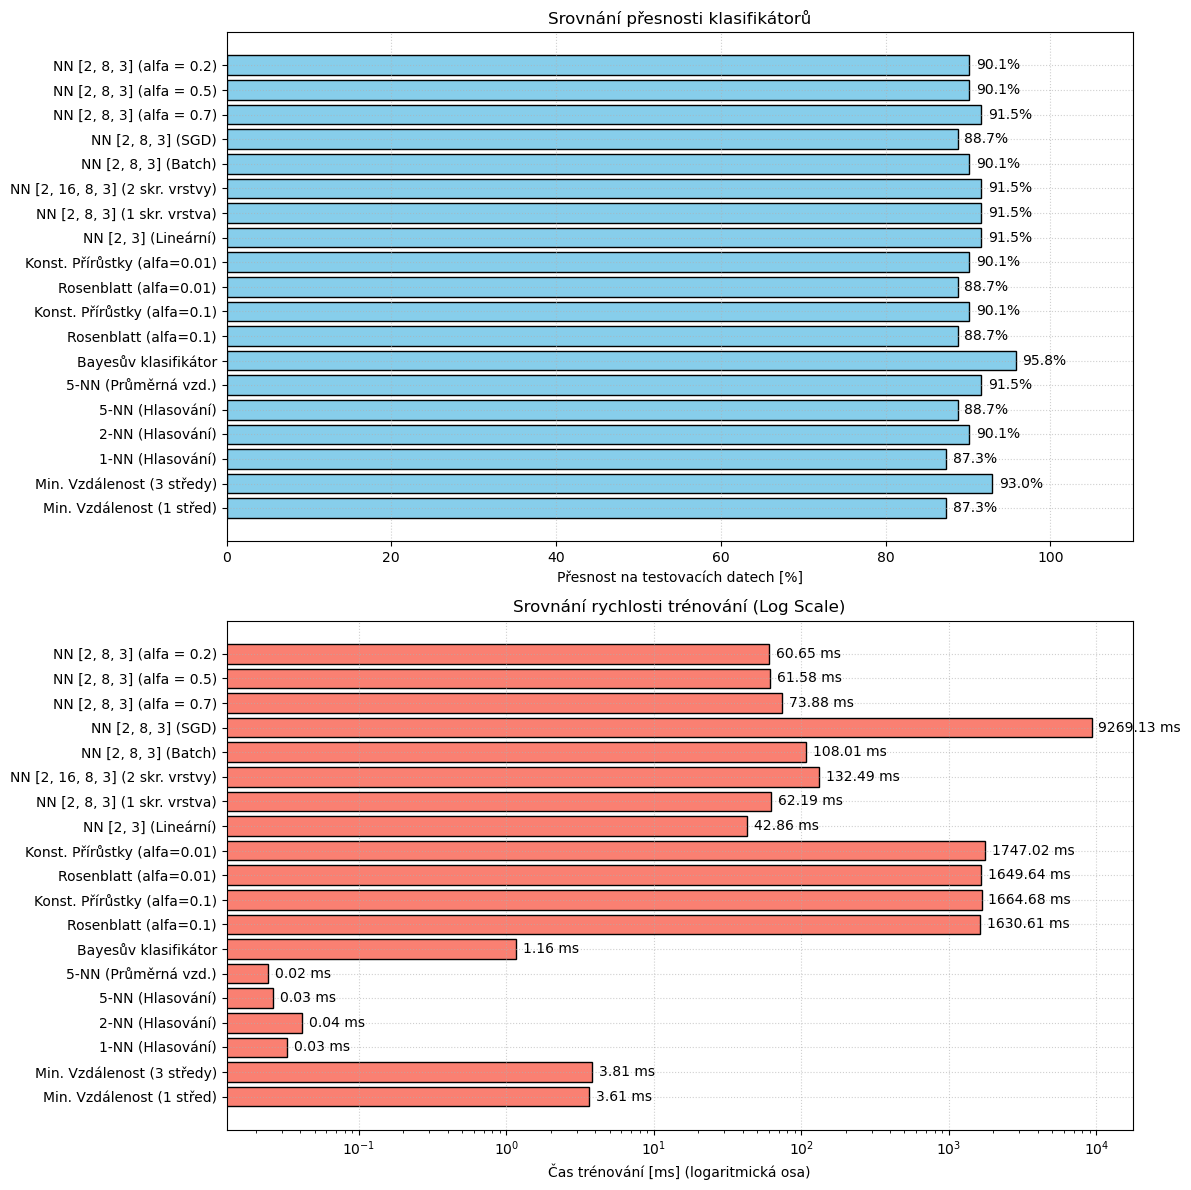

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# 1. Graf přesnosti
names = list(results_accuracy.keys())
accuracies = list(results_accuracy.values())
bars1 = ax1.barh(names, accuracies, color='skyblue', edgecolor='black')
ax1.set_xlim(0, 110)
ax1.set_xlabel('Přesnost na testovacích datech [%]')
ax1.set_title('Srovnání přesnosti klasifikátorů')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.bar_label(bars1, fmt='%.1f%%', padding=5)

# 2. Graf rychlosti trénování (logaritmické měřítko kvůli extrémním rozdílům)
times = list(results_time.values())
bars2 = ax2.barh(names, times, color='salmon', edgecolor='black')
ax2.set_xscale('log')
ax2.set_xlabel('Čas trénování [ms] (logaritmická osa)')
ax2.set_title('Srovnání rychlosti trénování (Log Scale)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.bar_label(bars2, fmt='%.2f ms', padding=5)

plt.tight_layout()
plt.show()

# Diskuze a vyhodnocení výsledků

Při interpretaci výsledků je nutné mít na paměti, že testovací množina obsahuje pouze cca **71 vzorků** (10 % dat). Každá jednotlivá chyba tak představuje změnu úspěšnosti o přibližně $1.4\ \text{p. b.}$ Přesné hodnoty přesnosti a času se proto při každém spuštění mírně liší, ale celkové trendy a vlastnosti algoritmů zůstávají stabilní.

---

## 1. Porovnání vlastností klasifikátorů

### A. Geometrické přístupy (Minimální vzdálenost)
* **1 centroid na třídu:** Nejrychlejší analytická metoda. Hranice jsou striktně lineární. Model však předpokládá kulovité rozdělení tříd, proto **selhává u protáhlých (elipsoidních) shluků**, kde odřezává okrajové body a vykazuje nižší přesnost.
* **Více centroidů (K-means):** Výrazné zlepšení přesnosti. Hranice se stává po částech lineární a dokáže se mnohem lépe přizpůsobit podlouhlému tvaru shluků za cenu zanedbatelného nárůstu času.

### B. Metody nejbližšího souseda (k-NN)
k-NN nepotřebuje fázi trénování (líné učení), ale výpočetní zátěž se přenáší do fáze predikce (vykreslení mřížky).
* **1-NN vs. 5-NN:** 1-NN trpí přeučením a vytváří zubaté, šumem ovlivněné hranice. Vyšší $k=5$ hranice vyhlazuje a zvyšuje robustnost.
* **2-NN (Problém sudého $k$):** Často naráží na nerozhodné stavy (shoda hlasů 1:1), což vytváří nepřirozené anomálie na rozhraní tříd.
* **Hlasování vs. Průměrná vzdálenost:** Metoda průměrné vzdálenosti k sousedům dává podstatně hladší rozhodovací hranice, které lépe respektují hustotu shluků a dosahují stabilnějších výsledků.

### C. Bayesův klasifikátor (QDA)
* **Vítěz z hlediska přesnosti a stability.** Jelikož data pocházejí z normálních rozdělení, Bayesův klasifikátor dokáže analyticky odhadnout nejen těžiště, ale i rotaci a rozptyly shluků (kovarianční matice).
* **Hranice a rychlost:** Generuje hladké, kvadraticky zakřivené hranice. Výpočet je bleskový (řádově milisekundy), což z něj činí nejvhodnější model pro tento typ dat.

### D. Lineární diskriminační funkce (Rosenblatt vs. Konstantní přírůstky)
Oba algoritmy generují striktně lineární přímky a jsou výpočetně pomalejší kvůli iterování v čistém Pythonu.
* **Rosenblatt:** Zastaví učení v momentě, kdy najde jakékoliv oddělení. Výsledná přímka je často nalepená těsně na okrajích shluků.
* **Konstantní přírůstky:** Pomocí pásma necitlivosti $b > 0$ tlačí rozhodovací přímky dál od okrajů shluků (vytváří bezpečnostní odstup), což vede k lepší schopnosti zobecnění a vyšší testovací přesnosti, byť za cenu většího počtu iterací.

---

## 2. Analýza experimentů s Neuronovou sítí (MLP)

Neuronová síť (MLP) umožňuje modelovat velmi složité nelineární hranice, ale vyžaduje nejvíce výpočetního času.

* **Topologie sítě:** Lineární model bez skryté vrstvy `[2, 3]` konverguje v prvních epochách velmi strmě (optimalizuje jednodušší prostor), ale jeho přesnost je omezená. Vícevrstvé sítě (`[2, 8, 3]` a `[2, 16, 8, 3]`) sice začínají s vyšší chybou, ale nelineární skryté vrstvy jim nakonec umožní dosáhnout lepšího rozhraní tříd.
* **Optimalizace (SGD vs. Batch GD):**
  * **Batch GD:** Loss klesá hladce, ale velmi pomalu, protože váhy aktualizuje pouze jednou za epochu. Po 300 epochách bývá síť často nedotrénovaná.
  * **SGD:** Loss vykazuje drobný šum (způsobený aktualizací po každém vzorku), ale konverguje extrémně rychle (již během prvních epoch dosahuje optimálního stavu).
  * **Časová náročnost:** Trénování SGD v čistém Pythonu trvá řádově nejdéle (sekundy vs. milisekundy u Batch GD) kvůli režii sekvenčního zpracování dat.
* **Konstanta učení (Learning Rate):** Vyšší konstanta (např. 0.7) urychluje konvergenci, ale nese riziko nestability. Příliš nízká konstanta (0.2) sice konverguje hladce, ale vyžaduje neekonomicky vysoký počet epoch.

---

## 3. Závěr

Pro tuto konkrétní datovou sadu se ukazuje, že **složitější model neznamená automaticky lepší výsledek**. 

**Bayesův klasifikátor** dosahuje nejvyšší přesnosti při téměř nulovém čase trénování ($10-15\ ms$). **Neuronová síť (SGD)** sice dokáže vygenerovat skvělé nelineární hranice, ale její trénování trvá kvůli sekvenčnímu zpracování v čistém Pythonu nejdéle (okolo $9\ s$). Pro praktické nasazení na těchto datech je nejvhodnější volbou analytický **Bayesův klasifikátor**, případně robustní **5-NN s průměrnou vzdáleností**.